## File Path Initialization

In [240]:
teenmh_path = "Teen_Mental_Health_Dataset.csv"

print("Path to dataset files:", teenmh_path)

Path to dataset files: Teen_Mental_Health_Dataset.csv


## Data Description


In [241]:
import pandas as pd

teenmh_data = pd.read_csv(teenmh_path)
teenmh_data.describe()


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## Declaration of X and Y

In [242]:
y = teenmh_data.academic_performance
feature_columns = [
    'age', 
    'gender', #
    'daily_social_media_hours', 
    'platform_usage', #
    'sleep_hours', 
    'screen_time_before_sleep', 
    'physical_activity', 
    'social_interaction_level', #
    'stress_level', 
    'anxiety_level', 
    'addiction_level', 
    # 'depression_label'
]
X = teenmh_data[feature_columns]
X = pd.get_dummies(X, columns=['gender', 'platform_usage', 'social_interaction_level'])

## Trial Model Fitting (No Train Test Split Yet)

In [243]:
from sklearn.tree import DecisionTreeRegressor

teenmh_model = DecisionTreeRegressor()
teenmh_model.fit(X, y)

feature_importance = pd.Series(
    teenmh_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print(feature_importance.head(10))

print("First in-sample predictions:", teenmh_model.predict(X.head()))
print("Actual target values:", y.head().tolist())

daily_social_media_hours    0.164592
screen_time_before_sleep    0.126061
physical_activity           0.124064
sleep_hours                 0.116049
addiction_level             0.088004
stress_level                0.084141
age                         0.083146
anxiety_level               0.075483
gender_female               0.024611
gender_male                 0.024250
dtype: float64
First in-sample predictions: [3.01 3.22 3.92 3.48 2.37]
Actual target values: [3.01, 3.22, 3.92, 3.48, 2.37]


## Train Test Splitting

In [244]:
from sklearn.model_selection import train_test_split

train_X, val_X, train_y, val_y = train_test_split(X, y)

## Specify and Fit Model

In [245]:
teenmh_model = DecisionTreeRegressor()
teenmh_model.fit(train_X, train_y)
print("Number of leaves:", teenmh_model.tree_.n_leaves)


Number of leaves: 890


## Make Predictions with Validation Data

In [246]:
val_predictions = teenmh_model.predict(val_X)
print(val_predictions[0:5])
print(val_y.head().tolist())

[2.1  3.82 2.68 2.04 2.52]
[3.8, 3.59, 2.18, 3.33, 2.56]


## Calculate Mean Absolute Error in Validation Data

In [247]:
from sklearn.metrics import mean_absolute_percentage_error

val_mae = mean_absolute_percentage_error(val_y, val_predictions)
print("{:.4%}".format(val_mae))

24.6335%


## Adjusting Fit

{2: 0.17651552084597025, 3: 0.17730059367983703, 4: 0.17827904278218729, 5: 0.17973624225575813, 6: 0.18063646430861222, 7: 0.18170808778019298, 8: 0.18186058903514443, 9: 0.1827992713768478, 10: 0.18397683142660548, 11: 0.18496081099174963, 12: 0.18485853221930448, 13: 0.18452306975352936, 14: 0.1848731276358797, 15: 0.18751464777729776, 16: 0.18750877721891454, 17: 0.1872557845094418, 18: 0.18724047575393554, 19: 0.18929944531204076, 20: 0.18980802907186914, 21: 0.1897314603556609, 22: 0.19304215507438452, 23: 0.1932765156150332, 24: 0.19278122415033985}


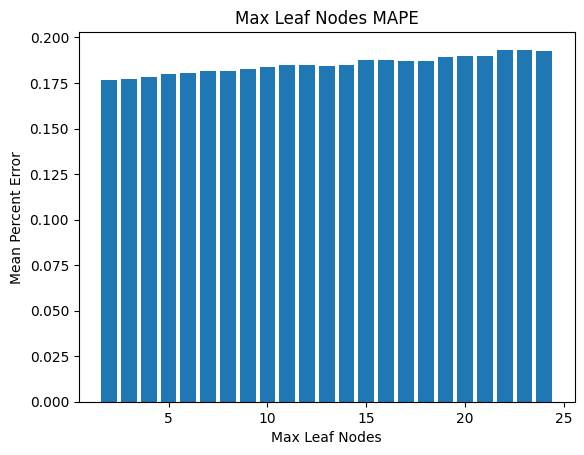

In [248]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

def get_mae(model_type, max_leaf_nodes, train_X, val_X, train_y, val_y):
    model = model_type(max_leaf_nodes=max_leaf_nodes)
    model.fit(train_X, train_y)
    val_predictions = model.predict(val_X)
    mae = mean_absolute_percentage_error(val_y, val_predictions)
    return mae

MLN = {}
for max_leaf_nodes in range(2, 25):
    MLN[max_leaf_nodes] = get_mae(DecisionTreeRegressor, max_leaf_nodes, train_X, val_X, train_y, val_y)
    # print("{} Max Leaf Nodes: {:.2%}".format(max_leaf_nodes, get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)))
# print("{} Max Leaf Nodes: {:.2%}".format(teenmh_model.tree_.n_leaves, get_mae(max_leaf_nodes, train_X, val_X, train_y, val_y)))

print(MLN)
plt.bar(list(MLN.keys()), list(MLN.values()))
plt.title('Max Leaf Nodes MAPE')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('Mean Percent Error')
plt.show()


## Using Random Forest Model

2


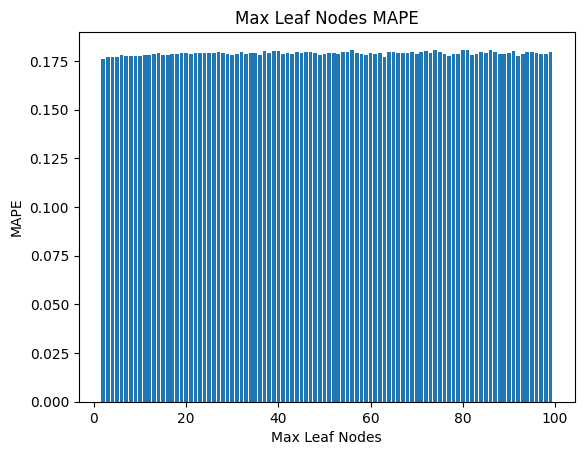

In [251]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor()
forest_model.fit(train_X, train_y)
forest_predictions = forest_model.predict(val_X)

MLN = {}
for max_leaf_nodes in range(2, 100):
    MLN[max_leaf_nodes] = get_mae(RandomForestRegressor, max_leaf_nodes, train_X, val_X, train_y, val_y)

print(min(list(MLN.keys())))
plt.bar(list(MLN.keys()), list(MLN.values()))
plt.title('Max Leaf Nodes MAPE')
plt.xlabel('Max Leaf Nodes')
plt.ylabel('MAPE')
plt.show()
